# Visualize CLASP Embedding

Load optimized parameters saved by notebook 01 when available; otherwise use the selected dataset defaults. Then run the embedding, plot it, and save the embedded AnnData file for evaluation.


In [8]:
from clasp.notebook_utils import (
    DATASET_REGISTRY,
    dataset_config,
    embed_dataset,
    load_or_default_params,
    load_preprocessed_data,
    make_estimator,
)


selected_dataset = "scib_immune_human_mouse"
dataset = dataset_config(selected_dataset)
optimized_params = load_or_default_params(selected_dataset, dataset)

# Use saved/default preprocessing settings; max_cells can be increased for final visualization.
preprocess_overrides = {
    **optimized_params.get("preprocess_params", {}),
    "max_cells": 6000,
}
estimator_params = optimized_params.get("estimator_params", {})
graph_params = optimized_params["graph_params"]

estimator = make_estimator(dataset, random_state=0, **estimator_params)
input_path = dataset["input_path"]
output_path = dataset["output_path"]
batch_key = dataset["batch_key"]
label_key = dataset["label_key"]

selected_dataset, optimized_params["source"], input_path, output_path, batch_key, label_key


('scib_immune_human_mouse',
 'optimized',
 PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/clasp/data/Immune_ALL_hum_mou.h5ad'),
 PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/clasp/data/Immune_ALL_hum_mou-clasp.h5ad'),
 'batch',
 'final_annotation')

In [9]:
optimized_params


{'dataset': 'scib_immune_human_mouse',
 'estimator_params': {'n_components': 65},
 'graph_params': {'assignment_quantile': 0.42200445502525735,
  'edge_weighting': 'binary',
  'hubness_correction': 'csls',
  'hubness_k': 14,
  'intra_fraction': 0.31466783575798185,
  'metric': 'euclidean',
  'mutual_neighbors': False,
  'n_inter_edges': 4,
  'n_neighbors': 28,
  'neighbor_mode': 'distance',
  'rank_correction': True,
  'symmetrize': True},
 'metadata': {'best_model': 'gplvm',
  'best_score': 0.61075,
  'fixed_preprocess_params': {'max_cells': 1000},
  'gplvm_best_score': 0.61075,
  'pca_best_score': 0.59775,
  'random_state': 0},
 'preprocess_params': {'create_artificial_batch': False,
  'hvg_flavor': 'variance',
  'max_cells': 1000,
  'min_cell_genes': None,
  'min_gene_counts': 0,
  'n_top_genes': 1520,
  'normalize': False},
 'source': 'optimized',
 'path': '/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/clasp/data/optimized_params/scib_immune_human_mouse_graph_params.json'}

In [10]:
adata = load_preprocessed_data(estimator, dataset, **preprocess_overrides)
adata


AnnData object with n_obs × n_vars = 6000 × 1520
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'size_factors', 'species', 'study', 'tissue'
    var: 'clasp_hvg_score', 'clasp_selected'
    obsm: 'X_pca'
    layers: 'counts'

In [11]:
adata = embed_dataset(adata, estimator, graph_params)
graph_params


{'assignment_quantile': 0.42200445502525735,
 'edge_weighting': 'binary',
 'hubness_correction': 'csls',
 'hubness_k': 14,
 'intra_fraction': 0.31466783575798185,
 'metric': 'euclidean',
 'mutual_neighbors': False,
 'n_inter_edges': 4,
 'n_neighbors': 28,
 'neighbor_mode': 'distance',
 'rank_correction': True,
 'symmetrize': True}

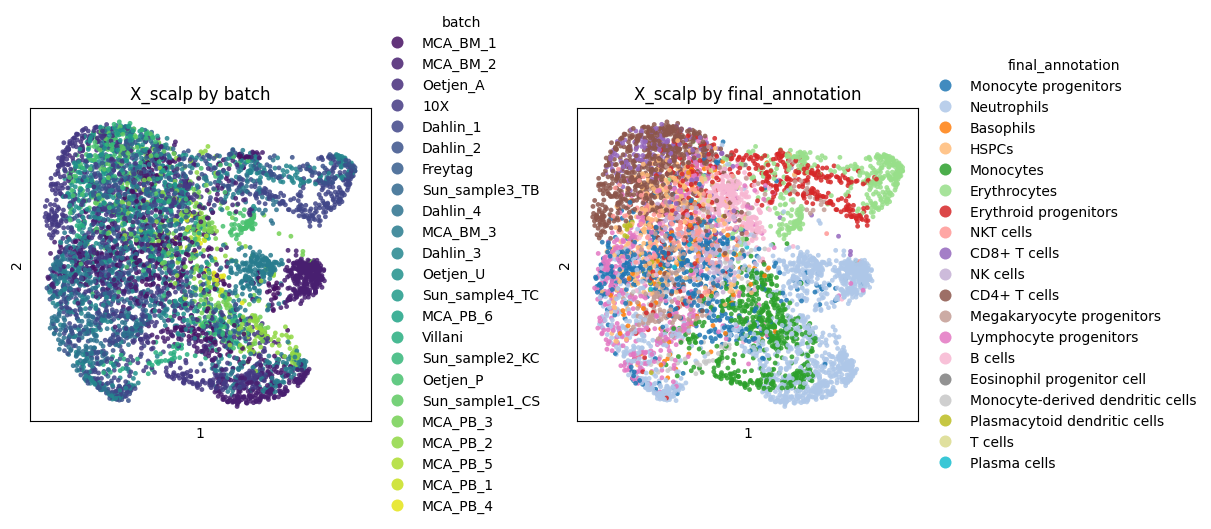

In [12]:
estimator.plot(adata, embedding_key="X_clasp");


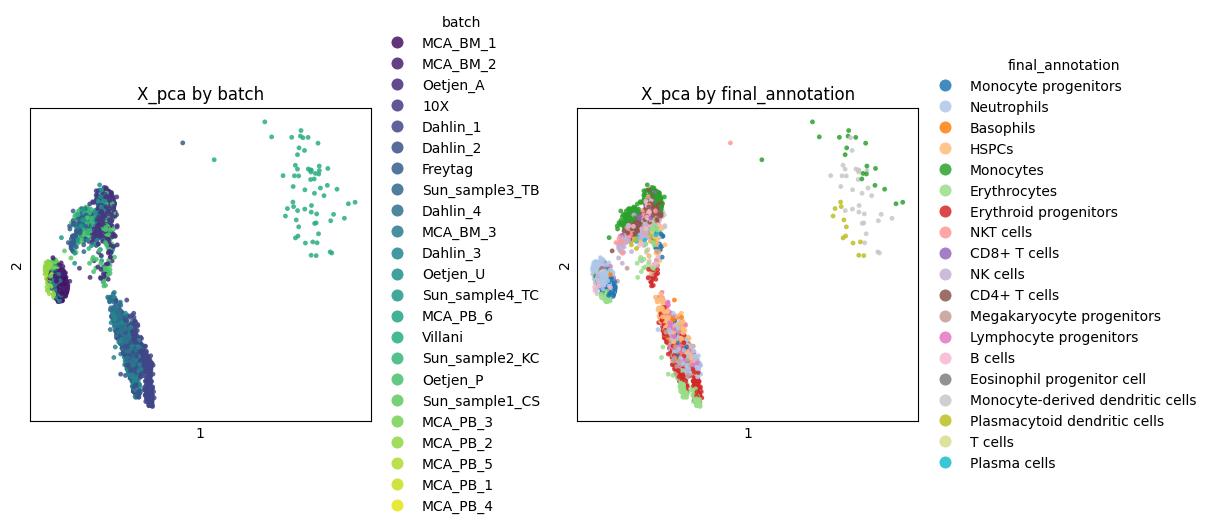

In [13]:
estimator.plot(adata, embedding_key="X_pca");


In [14]:
estimator.save(adata, output_path)
output_path


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/clasp/data/Immune_ALL_hum_mou-clasp.h5ad')